# scvelo VASA-seq

In [1]:
import scvelo as scv
import scanpy as sc
import numpy as np
import anndata as ad
from scipy import sparse
import glob, os

scv.settings.verbosity = 3  # show errors(0), warnings(1), info(2), hints(3)
scv.settings.presenter_view = True  # set max width size for presenter view
scv.settings.set_figure_params('scvelo')  # for beautified visualization

spliced and unspliced counts were downloaded from GEO:

https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE176588

In [ ]:
#stage = "E9.5"
stage = ""
sfiles = glob.glob("../vasa/count/*_"+stage+"*_spliced*.gz")
ufiles = glob.glob("../vasa/count/*_"+stage+"*_unspliced*.gz")
sfiles.sort()
ufiles.sort()
# sample ids
sid = [os.path.basename(f).split('_')[1] for f in sfiles]
sid

['E6.5-1',
 'E6.5-2',
 'E6.5-3',
 'E6.5-4',
 'E6.5-5',
 'E6.5-6',
 'E6.5-7',
 'E7.5-1',
 'E7.5-2',
 'E7.5-3',
 'E7.5-4',
 'E7.5-5',
 'E7.5-6',
 'E7.5-7',
 'E8.5-10',
 'E8.5-11',
 'E8.5-12',
 'E8.5-13',
 'E8.5-14',
 'E8.5-15',
 'E8.5-16',
 'E8.5-17',
 'E8.5-19',
 'E8.5-1',
 'E8.5-20',
 'E8.5-21',
 'E8.5-22',
 'E8.5-23',
 'E8.5-2',
 'E8.5-3',
 'E8.5-4',
 'E8.5-5',
 'E8.5-6',
 'E8.5-7',
 'E8.5-8',
 'E8.5-9',
 'E9.5-1',
 'E9.5-3',
 'E9.5-4',
 'E9.5-5',
 'E9.5-6',
 'E9.5-7',
 'E9.5-8',
 'E9.5-9']

In [4]:
sdatas = [sc.read(f,cache=True,delimiter="\t").T for f in sfiles]
udatas = [sc.read(f,cache=True,delimiter="\t").T for f in ufiles]
labels = [os.path.basename(f).split('_')[1].split('-') for f in sfiles]

# add prefix to cell id
for i in range(len(sdatas)):
    sdatas[i].obs.index = sid[i] + "_" + sdatas[i].obs.index
    udatas[i].obs.index = sid[i] + "_" + udatas[i].obs.index
    sdatas[i].X = sparse.csc_matrix(sdatas[i].X)
    udatas[i].X = sparse.csc_matrix(udatas[i].X)
    sdatas[i].obs['stage'] = [labels[i][0]]*len(sdatas[i].obs)
    udatas[i].obs['stage'] = [labels[i][0]]*len(udatas[i].obs)
    sdatas[i].obs['lot'] = [labels[i][1]]*len(sdatas[i].obs)
    udatas[i].obs['lot'] = [labels[i][1]]*len(udatas[i].obs)

# csc is fast for concat
sdata = ad.concat(sdatas)
udata = ad.concat(udatas)

Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', '.gz'].
Only considering the two last: ['.tsv', 

In [27]:
adata = scv.utils.merge(sdata,udata)
adata.layers['spliced'] = sdata[adata.obs.index,adata.var.index].X
adata.layers['unspliced'] = udata[adata.obs.index,adata.var.index].X
#adata.layers['spliced'] = 1e5*sdata[adata.obs.index,adata.var.index].X/sdata.X.sum()
#adata.layers['unspliced'] = 1e5*udata[adata.obs.index,adata.var.index].X/udata.X.sum()
varidx = adata.var.index.str.split('_')
adata.var['gene_id']   = [v[0] for v in varidx]
adata.var['gene_name'] = [v[1] for v in varidx]
adata.var['gene_type'] = [v[2] for v in varidx]
adata.var.index = [v[1] for v in varidx]
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 46124 × 17076
    obs: 'stage', 'lot'
    var: 'gene_id', 'gene_name', 'gene_type'
    layers: 'spliced', 'unspliced'

In [28]:
adata.X.sum(), adata.layers["spliced"].sum(), adata.layers["unspliced"].sum()

(609999500.0, 609999500.0, 464339140.0)

In [ ]:
import pandas as pd
# Histone genes definition was taken from https://github.com/hemberg-lab/VASAseq_2022
histones = [s.split('_')[0] for s in pd.read_csv('../vasa/VASAseq_2022/I_Gene_expression/b_Analysis/HistoneGenes.tsv', sep = '\t', index_col = 0, header = None)[1]]
#list(histones[1])
adata.obs['n_counts'] = adata.X.sum(axis=1).A1
adata.obs['frac_mito'] = adata.X[:,adata.var_names.str.startswith('mt.')].sum(axis=1).A1/adata.obs['n_counts']
adata.obs['frac_histones'] = adata.X[:,[g in histones for g in adata.var_names]].sum(axis=1).A1/adata.obs['n_counts']
adata.write("../data/"+("all" if stage=="" else stage.replace('.',''))+"_vanilla.h5ad") # file to resume
adata.obs

,stage,lot,n_counts,frac_mito,frac_histones
E6.5-1_GCCTTGTGCCAGCAGT,E6.5,1,7235.0,0.005805,0.001935
E6.5-1_CCGTAGCTCAGTCCCT,E6.5,1,20237.0,0.004299,0.000988
E6.5-1_AGCTTCGATTAAACTG,E6.5,1,23772.0,0.009507,0.006941
E6.5-1_TACCGCTCCAGTTTGC,E6.5,1,28003.0,0.008285,0.018748
E6.5-1_TCCGCTGTGGTGGGAT,E6.5,1,37151.0,0.004953,0.021695
...,...,...,...,...,...
E9.5-9_CGAAGAAGGCCGGATT,E9.5,9,4601.0,0.007824,0.002391
E9.5-9_TGGGAATTGTCAAAGA,E9.5,9,5921.0,0.011147,0.021280
E9.5-9_AAACTACAAGAAGTCC,E9.5,9,6648.0,0.014140,0.028129
E9.5-9_CTGCTAGAGGCATGCT,E9.5,9,7422.0,0.009162,0.002425


In [30]:
adata.var[adata.var_names.str.startswith('mt.')]

,gene_id,gene_name,gene_type
mt.Rnr1,ENSMUSG00000064337,mt.Rnr1,MtRrna
mt.Tv,ENSMUSG00000064338,mt.Tv,MtTrna
mt.Rnr2,ENSMUSG00000064339,mt.Rnr2,MtRrna
mt.Nd1,ENSMUSG00000064341,mt.Nd1,ProteinCoding
mt.Tm,ENSMUSG00000064344,mt.Tm,MtTrna
mt.Nd2,ENSMUSG00000064345,mt.Nd2,ProteinCoding
mt.Tw,ENSMUSG00000064346,mt.Tw,MtTrna
mt.Tn,ENSMUSG00000064348,mt.Tn,MtTrna
mt.Co1,ENSMUSG00000064351,mt.Co1,ProteinCoding
mt.Co2,ENSMUSG00000064354,mt.Co2,ProteinCoding


In [57]:
if True: # set True if resume
    stage = ""
    adata = ad.read_h5ad("../data/scvelo_vasa_all_vanilla.h5ad") 

calculating cell cycle phase
-->     'S_score' and 'G2M_score', scores of cell cycle phases (adata.obs)
Filtered out 134 genes that are detected 20 counts (spliced).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
computing moments based on connectivities
    finished (0:00:06) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities


/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:18) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 32/48 cores)


  0%|          | 0/46124 [00:00<?, ?cells/s]

    finished (0:00:46) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


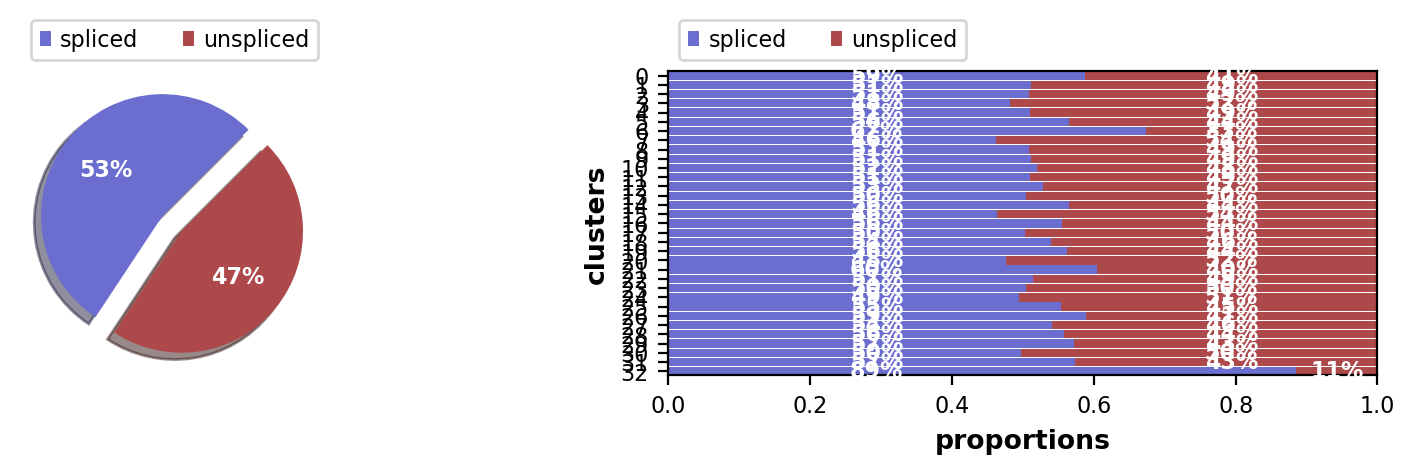

computing velocity embedding
    finished (0:00:12) --> added
    'velocity_pca', embedded velocity vectors (adata.obsm)


/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/plo

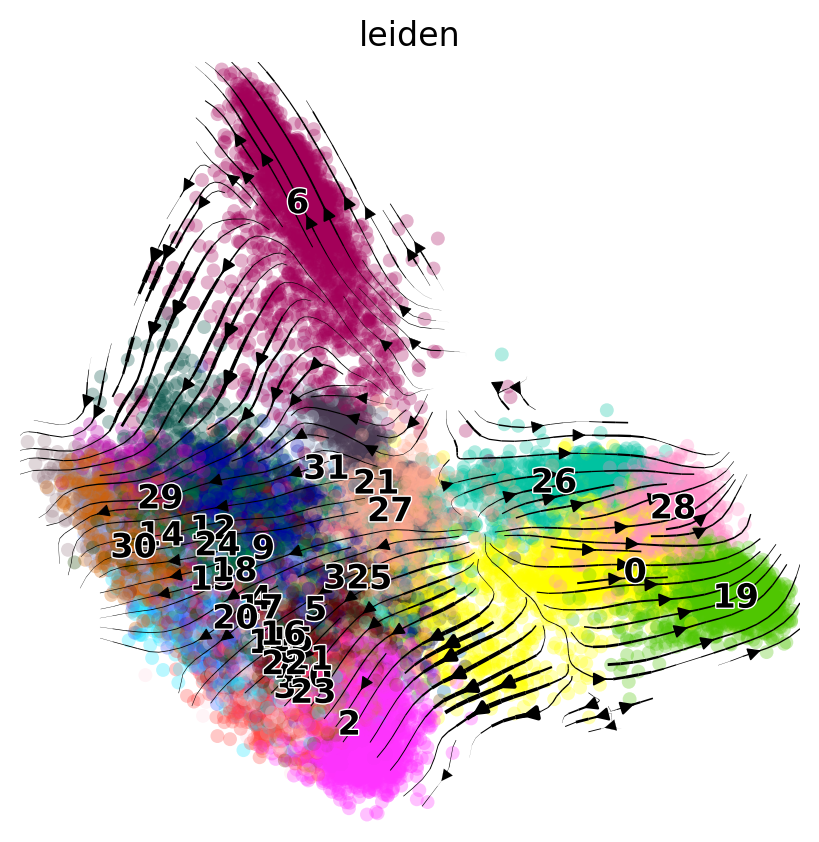

computing velocity embedding
    finished (0:00:07) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/plo

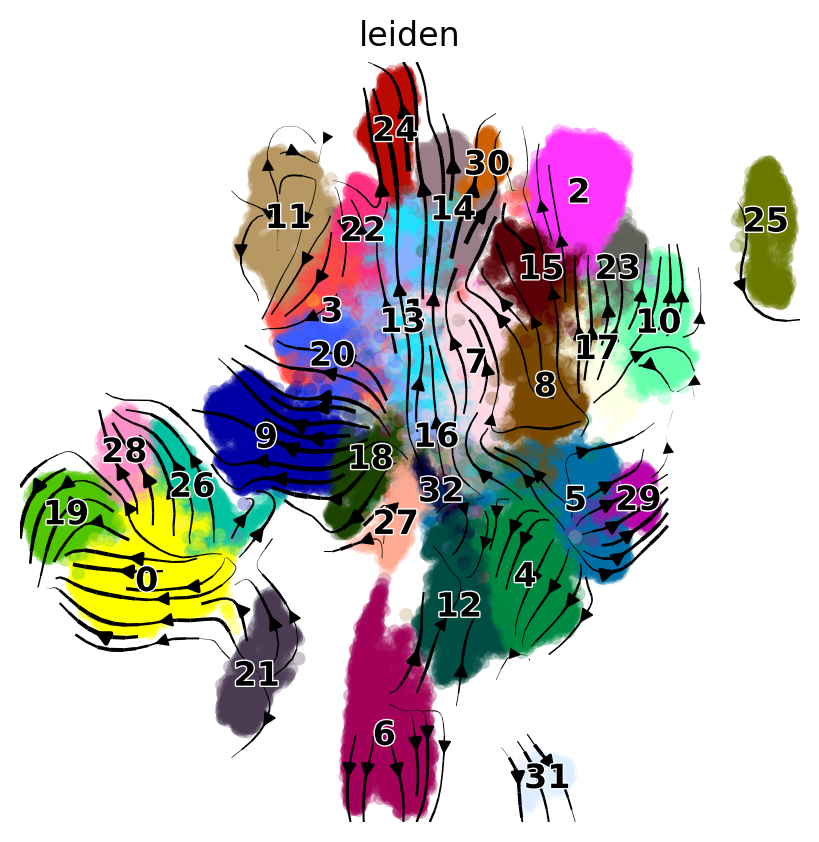

In [58]:
filename = "scvelo_vasa_"+("all" if stage=="" else stage.replace('.',''))+".h5ad"
adata = adata[:,adata.var.gene_type == "ProteinCoding"]
adata.raw = adata
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
#sc.pp.filter_cells(adata, min_genes=500)
scv.tl.score_genes_cell_cycle(adata)
#sc.pp.filter_genes(adata, min_cells=20)
scv.pp.filter_genes(adata, min_counts=20)
scv.pp.normalize_per_cell(adata)
#sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
scv.pp.filter_genes_dispersion(adata, n_top_genes=2000) # 3000 in Qiu
#scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=30)
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)
scv.tl.velocity(adata,mode="stochastic")
scv.tl.velocity_graph(adata,n_jobs=32)
#scv.tl.umap(adata,min_dist=0.8,maxiter=500,random_state=1231) # for scvelo < 0.3.3
sc.tl.umap(adata,min_dist=0.8,maxiter=500,random_state=1981)
sc.tl.leiden(adata)
adata.obs["clusters"] = adata.obs["leiden"]
scv.pl.proportions(adata,groupby='clusters')
#scv.pl.scatter(adata, color_gradients=['S_score', 'G2M_score'], smooth=True, perc=[5, 95],figsize=(5,5))
scv.pl.velocity_embedding_stream(adata, basis='pca',  color='leiden',size=100,figsize=(5,5))
scv.pl.velocity_embedding_stream(adata, basis='umap', color='leiden',size=100,figsize=(5,5))

In [59]:
adata

AnnData object with n_obs × n_vars = 46124 × 2000
    obs: 'stage', 'lot', 'n_counts', 'frac_mito', 'frac_histones', 'n_genes_by_counts', 'total_counts', 'S_score', 'G2M_score', 'phase', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'velocity_self_transition', 'leiden', 'clusters'
    var: 'gene_id', 'gene_name', 'gene_type', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'log1p', 'pca', 'neighbors', 'velocity_params', 'velocity_graph', 'velocity_graph_neg', 'umap', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap', 'velocity_pca', 'velocity_umap'
    varm: 'PCs'
    layers: 'spliced', 'unspliced', 'Ms', 'Mu', 'velocity', 'variance_velocity'
    obsp: 'distances', 'connectivities'

In [60]:
import celltypist
from celltypist import models
#models.download_models(force_update = False)

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 46124 cells and 2000 genes
🔗 Matching reference genes in the model
🧬 1464 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 20
🗳️ Majority voting the predictions
✅ Majority voting done!
/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/usr/local/packages/mambaforge/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is depreca

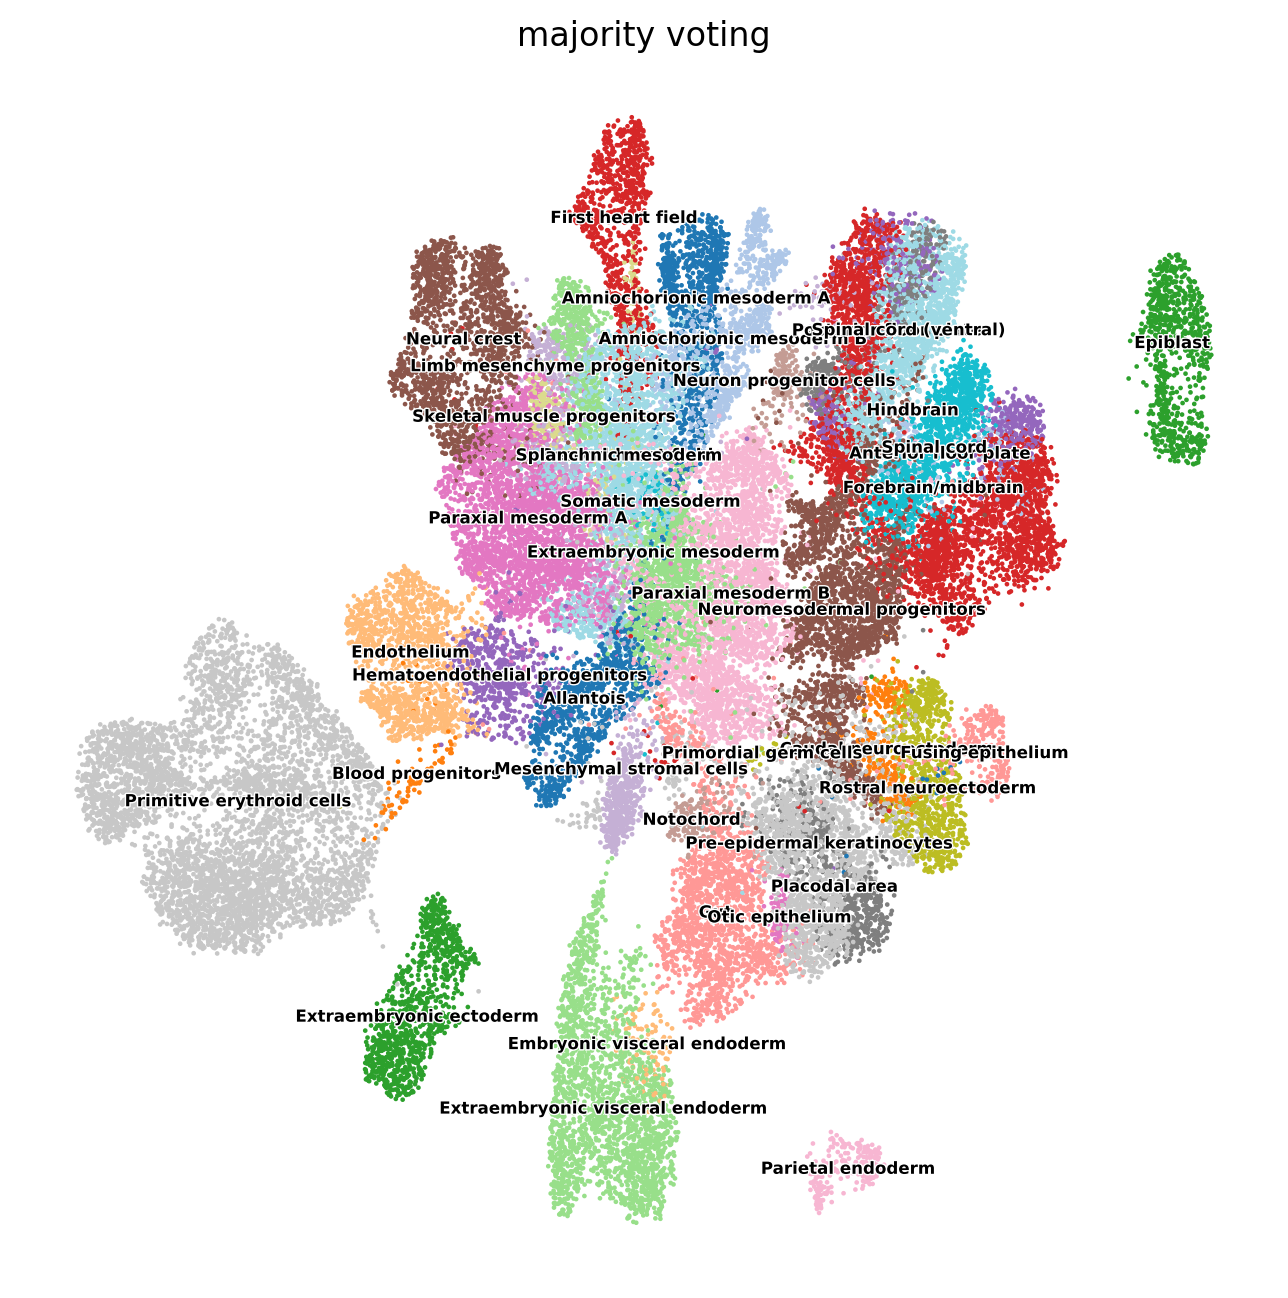

In [61]:
pkl = '../data/Qiu2022_celltype.pkl'
model = models.Model.load(model = pkl)
predictions = celltypist.annotate(adata, model = pkl, majority_voting = True)
predictions.predicted_labels
adataa = predictions.to_adata()
adata.obs['qiu2022'] = adata.obs.majority_voting
scv.pl.umap(adataa, color = 'majority_voting',figsize=(8,8), legend_loc='on data', legend_fontsize=6, palette="tab20")

In [62]:
adataa.write("../data/"+filename)
adataa

AnnData object with n_obs × n_vars = 46124 × 2000
    obs: 'stage', 'lot', 'n_counts', 'frac_mito', 'frac_histones', 'n_genes_by_counts', 'total_counts', 'S_score', 'G2M_score', 'phase', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'velocity_self_transition', 'leiden', 'clusters', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'qiu2022'
    var: 'gene_id', 'gene_name', 'gene_type', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'log1p', 'pca', 'neighbors', 'velocity_params', 'velocity_graph', 'velocity_graph_neg', 'umap', 'leiden', 'leiden_colors', 'over_clustering', 'majority_voting_colors'
    obsm: 'X_pca', 'X_umap', 'velocity_pca', 'velocity_umap'
    varm: 'PCs'
    layers: 'spliced', 'unspliced', 'Ms', 'Mu', 'velocity', 'variance_velocity'
    